<a href="https://colab.research.google.com/github/arundhatimsb/assignment/blob/main/VAE_remote_sensing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [188]:
!pip install torch torchvision matplotlib scikit-learn

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import transforms
from torchvision.datasets import EuroSAT
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
# import numpy as np

In [189]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

dataset = EuroSAT(root="data", transform=transform, download=True)

dataset_size = len(dataset)
traindata_size = int(0.7 * dataset_size)
valdata_size = int(0.15 * dataset_size)
testdata_size = dataset_size - traindata_size - valdata_size


In [190]:
traindataset, valdataset, testdataset = random_split(
    dataset,
    [traindata_size, valdata_size, testdata_size]
)

train_loader = DataLoader(traindataset,
                          batch_size=64,
                          shuffle=True,
                          num_workers=2,
                          pin_memory=True)
val_loader = DataLoader(valdataset,
                        batch_size=64,
                        shuffle=False)

test_loader = DataLoader(testdataset,
                         batch_size=64,
                         shuffle=False)

print("Total Images: ",dataset_size)
print("Training images:", len(traindataset))
print("Validation images:", len(valdataset))
print("Test images:", len(testdataset))
print("classes: ", dataset.classes)

Total Images:  27000
Training images: 18900
Validation images: 4050
Test images: 4050
classes:  ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


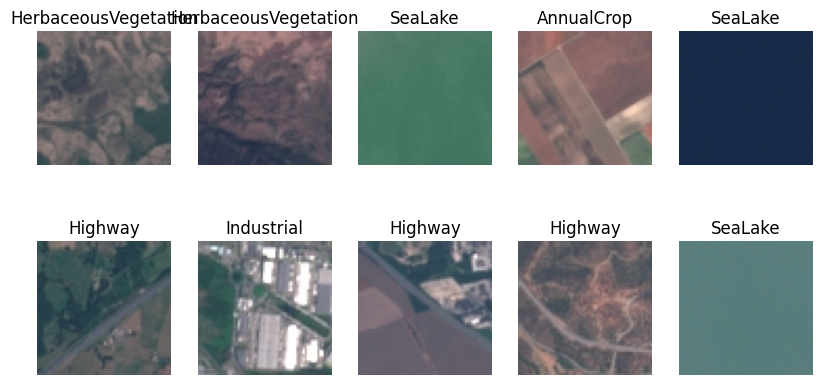

In [191]:
# img, label = dataset[0]
# plt.imshow(img.permute(1,2,0))
# plt.title(dataset.classes[label])
# plt.axis("off");

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    img, label = traindataset[i]
    ax.imshow(img.permute(1,2,0))
    ax.set_title(dataset.classes[label])
    ax.axis("off")

In [192]:
class Encoder(nn.Module):
  def __init__(self, latent_dim = 32):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(3,32,4,2,1),
        nn.ReLU(),
        nn.Conv2d(32,64,4,2,1),
        nn.ReLU(),
        nn.Conv2d(64,128,4,2,1),
        nn.ReLU(),
        nn.Conv2d(128,256,4,2,1),
        nn.ReLU()
    )
    self.fc_mean = nn.Linear(4096, latent_dim)
    self.fc_logvar = nn.Linear(4096, latent_dim)

  def forward(self, x):
    x = self.conv(x)
    x = x.view(x.size(0),-1)
    mean = self.fc_mean(x)
    logvar = self.fc_logvar(x)
    z = self.reparameterize(mean, logvar)
    return z, mean, logvar

  def reparameterize(self,mean, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mean + eps * std



In [193]:
class Decoder(nn.Module):
  def __init__(self, latent_dim = 32):
    super().__init__()

    self.fc = nn.Linear(latent_dim, 4096)

    self.deconv = nn.Sequential(
      nn.ConvTranspose2d(256,128,4,2,1),
      nn.ReLU(),
      nn.ConvTranspose2d(128,64,4,2,1),
      nn.ReLU(),
      nn.ConvTranspose2d(64,32,4,2,1),
      nn.ReLU(),
      nn.ConvTranspose2d(32,3,4,2,1),
      nn.Sigmoid()
    )
  def forward(self,z):
    x = self.fc(z)
    x = x.view(-1, 256, 4, 4)
    x = self.deconv(x)
    return x

In [194]:
class VAE(nn.Module):

    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self,x):
        z, mean, logvar = self.encoder(x)
        recon = self.decoder(z)
        return recon, mean, logvar

In [195]:
def loss_function(recon_x, x, mean, logvar):
    recon_loss = F.mse_loss(recon_x,x,reduction='sum')
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mean.pow(2) - logvar.exp()
    )
    return recon_loss + kl_loss

In [196]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.002)
epochs = 32
train_losses = []
validation_losses = []
for epoch in range(epochs):
  total_loss = 0
  # print(epoch)
  for x,_ in train_loader:
    # print(x)
    # print(_)
    x = x.to(device)
    optimizer.zero_grad()
    recon, mean, logvar = model(x)
    loss = loss_function(recon,x,mean,logvar)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  model.eval()
  total_val_loss = 0
  with torch.no_grad():
    for x, _ in val_loader:
      x = x.to(device)
      recon, mean, logvar = model(x)
      loss = loss_function(recon, x, mean, logvar)
      total_val_loss += loss.item()

  print(f"Epoch:{epoch+1},Training Loss:{total_loss: .3f}, validation loss: {total_val_loss: .3f}")
  train_losses.append(total_loss)
  validation_losses.append(total_val_loss)

Epoch:1,Training Loss: 2914888.093, validation loss:  454084.063
Epoch:2,Training Loss: 1911266.635, validation loss:  453283.124
Epoch:3,Training Loss: 1814731.478, validation loss:  395333.202
Epoch:4,Training Loss: 1729617.168, validation loss:  377278.625
Epoch:5,Training Loss: 1712866.533, validation loss:  372640.285
Epoch:6,Training Loss: 1669056.482, validation loss:  358685.192
Epoch:7,Training Loss: 1642520.732, validation loss:  392552.923
Epoch:8,Training Loss: 1625468.407, validation loss:  349526.570
Epoch:9,Training Loss: 1581042.086, validation loss:  346233.042
Epoch:10,Training Loss: 1538863.328, validation loss:  339557.332
Epoch:11,Training Loss: 1515628.610, validation loss:  326787.527
Epoch:12,Training Loss: 1502221.671, validation loss:  322826.355
Epoch:13,Training Loss: 1488591.058, validation loss:  338509.281
Epoch:14,Training Loss: 1478465.912, validation loss:  337000.877
Epoch:15,Training Loss: 1478927.508, validation loss:  324649.706
Epoch:16,Training L

Text(0, 0.5, 'Loss')

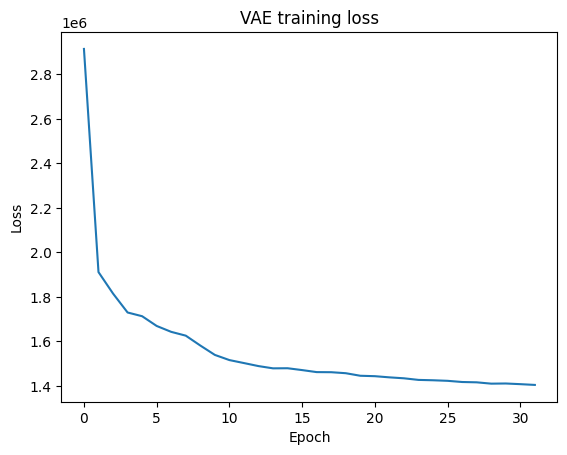

In [197]:
plt.figure()
plt.plot(train_losses)
plt.title('VAE training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

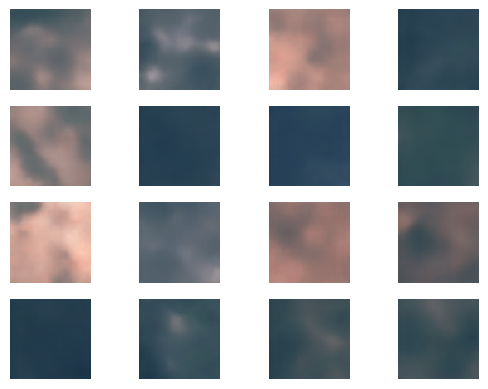

In [198]:
z = torch.randn(16,32).to(device)
samples = model.decoder(z)
samples = samples.cpu().detach()
fig,ax = plt.subplots(4,4)
k=0
for i in range(4):
    for j in range(4):
        ax[i,j].imshow(samples[k].permute(1,2,0))
        ax[i,j].axis('off')
        k+=1

In [199]:
img1,label1 = testdataset[0]
img2,label2 = testdataset[3]
print("distinct images: ",dataset.classes[label1],dataset.classes[label2])
img1 = img1.unsqueeze(0).to(device)
img2 = img2.unsqueeze(0).to(device)

_,mean1,_ = model.encoder(img1)
_,mean2,_ = model.encoder(img2)

images = []

for alpha in torch.linspace(0,1,10):

    z = (1-alpha)*mean1 + alpha*mean2

    img = model.decoder(z)

    images.append(img)

distinct images:  HerbaceousVegetation Industrial


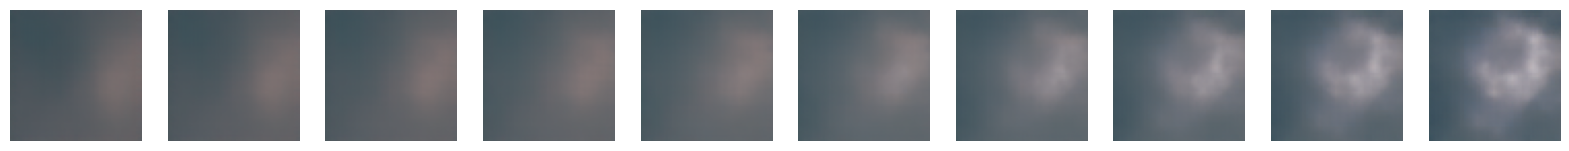

In [200]:
fig,ax = plt.subplots(1,10,figsize=(20,3))

for i,img in enumerate(images):

    ax[i].imshow(img.squeeze().permute(1,2,0).cpu().detach())
    ax[i].axis('off')

In [201]:
forest_latents = []
forest_img = None
for x,label in testdataset:
    if label == dataset.class_to_idx['Forest']:
        forest_img = x
        x = x.unsqueeze(0).to(device)
        _, mean,_ = model.encoder(x)

        forest_latents.append(mean)
forest_vector = torch.mean(torch.cat(forest_latents),0)

In [202]:
highway_latents = []
highway_img = None
for x,label in testdataset:
    if label == dataset.class_to_idx['Highway']:
        highway_img = x
        x = x.unsqueeze(0).to(device)
        _,mean,_ = model.encoder(x)
        highway_latents.append(mean)
highway_vector = torch.mean(torch.cat(highway_latents),0)

In [203]:
paving_vector =  highway_vector - forest_vector

In [204]:
river_img_plt = None
for x,label in testdataset:
    if label == dataset.class_to_idx['River']:
        river_img_plt = x
river_img = river_img_plt
river_img_plt = river_img
river_img = river_img.unsqueeze(0).to(device)
_,mean,_ = model.encoder(river_img)
new_z = mean + paving_vector
result = model.decoder(new_z)

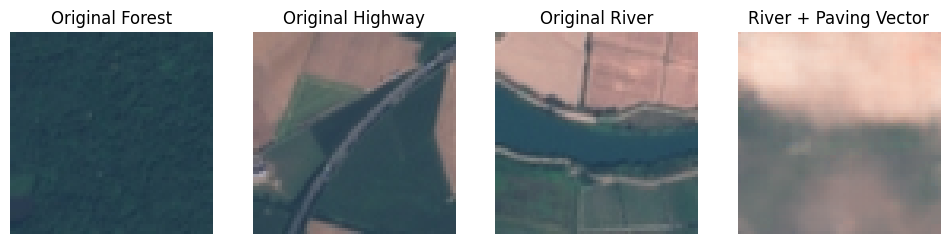

In [205]:
fig, ax = plt.subplots(1,4, figsize=(12,3))

ax[0].imshow(forest_img.permute(1,2,0))
ax[0].set_title("Original Forest")
ax[0].axis("off");

ax[1].imshow(highway_img.permute(1,2,0))
ax[1].set_title("Original Highway")
ax[1].axis("off");

ax[2].imshow(river_img_plt.permute(1,2,0))
ax[2].set_title("Original River")
ax[2].axis("off");

ax[3].imshow(result.squeeze().permute(1,2,0).cpu().detach())
ax[3].set_title("River + Paving Vector")
ax[3].axis("off");
